In [11]:
import numpy as np
import matplotlib.pyplot as plt
from bezierv.classes.distfit import DistFit
import scipy.stats as stats
import pandas as pd

In [22]:
simio_arrival_times_call_center = pd.read_excel('data\Problem_Dataset_06_01.xlsx')
simio_call_durations_call_center = pd.read_excel('data\Problem_Dataset_06_02.xlsx')
law_interarrival_times = pd.read_csv('data\interarrival_times.csv')
prob_list = [simio_arrival_times_call_center, simio_call_durations_call_center, law_interarrival_times]
names = ["Call center arrival times", "Call center call duration times", "Interarrival times"]

In [24]:
def analyze_data_batches(data_list, names_list):
    for i, data_batch in enumerate(data_list):
        # 1. Prepare Data
        data = np.array(data_batch.iloc[:, 0])
        data = data[np.isfinite(data)]
        fitter = DistFit(data, n=6) 
        bz, mse = fitter.fit(method="nonlinear")
        print("MSE: ", mse)
        try:
            cdf_vectorized = np.vectorize(bz.cdf_x)
            ks_stat, p_value = stats.kstest(data, cdf_vectorized)
            
            ks_result = f"KS Stat: {ks_stat:.1f}\nP-Value: {p_value:.1e}"
            print(f"  -> {ks_result.replace(chr(10), ' | ')}")
            
            box_color = '#ffdddd' if p_value < 0.05 else '#ddffdd'
            
        except Exception as e:
            ks_result = "KS Test Failed"
            box_color = 'white'
            print(f"  -> KS Error: {e}")

        fig, (ax_pdf, ax_cdf) = plt.subplots(1, 2, figsize=(14, 5))
        
        ax_pdf.hist(data, bins='auto', density=True, alpha=0.4, 
                    color='gray', edgecolor='white', label='Histogram')
        
        bz.plot_pdf(data=np.sort(data), ax=ax_pdf, show=False)
        ax_pdf.set_title(f"{names_list[i]}: PDF + Histogram")

        bz.plot_cdf(data=data, ax=ax_cdf, show=False)
        
        ax_cdf.text(0.05, 0.95, ks_result, transform=ax_cdf.transAxes, 
                    verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9))
        
        ax_cdf.set_title(f"{names_list[i]}: CDF + KS test")
        
        plt.tight_layout()
        plt.show()

MSE:  6.0793135932165615e-05
  -> KS Stat: 0.0 | P-Value: 1.0e+00


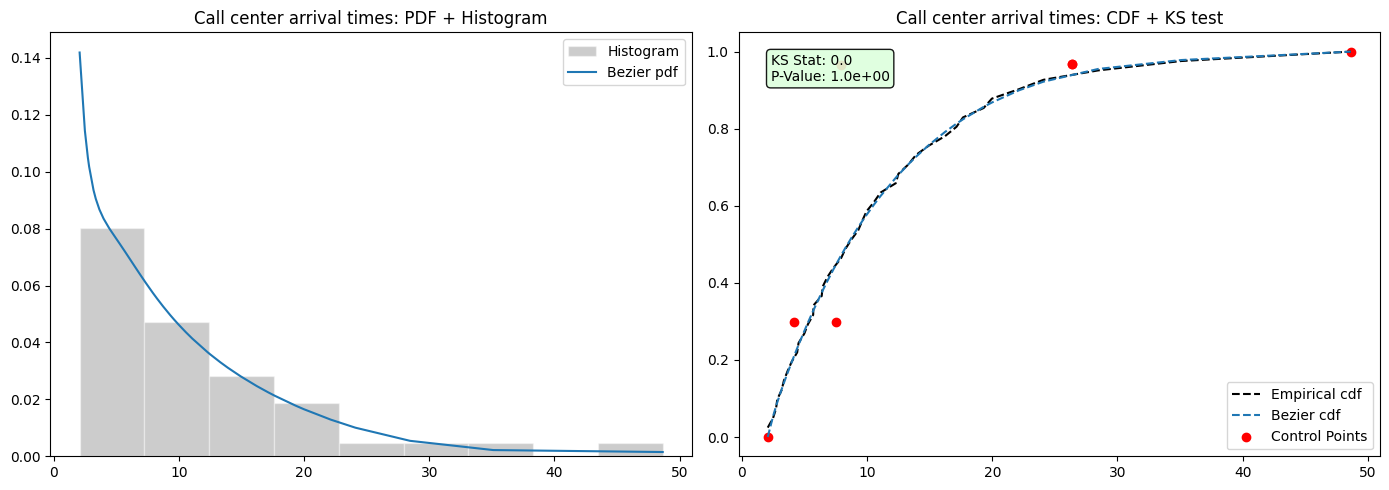

MSE:  4.494863831141443e-05
  -> KS Stat: 0.0 | P-Value: 1.0e+00


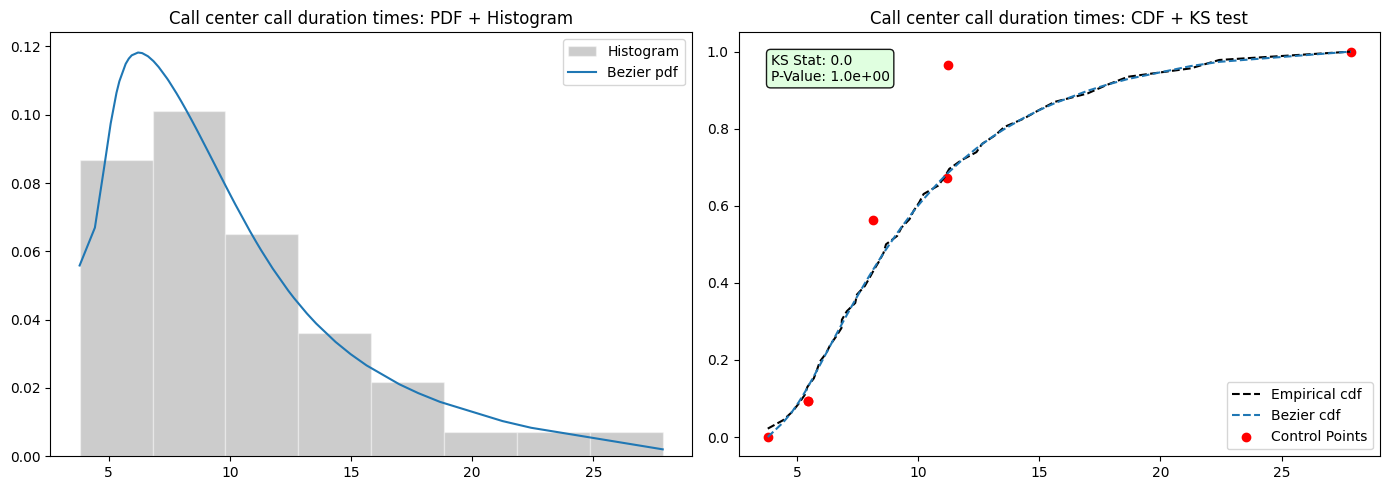

MSE:  0.000139071342576177
  -> KS Stat: 0.0 | P-Value: 6.4e-01


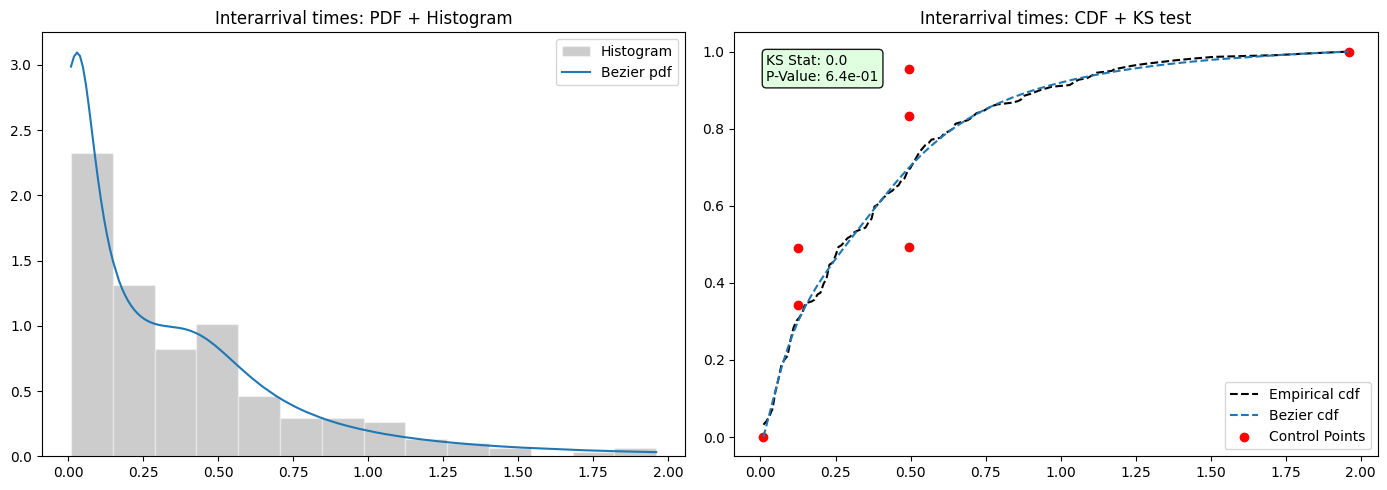

In [25]:
analyze_data_batches(prob_list, names)